# Per-Method Statistics (AV2 val) - no join

Each method is evaluated on its **own** cleaned row set. **No inner join.** This is the right way to read these stats when the three methods clean to very different sizes (ours: heavy stop-and-go + physical-sanity filter; KDSC/TDBM: minimal cleaning), because joining throws away every row not in the intersection and collapses the baselines' aggressive counts to ~0.

For each method we report, on that method's full row set:

1. Number of agents in each cluster.
2. Mean prediction error per cluster (`mtr_minfde6` primary; `mtr_minade6`, `cv_fde`, `cv_ade`, `mtr_miss_rate` secondary).
3. Histograms of kinematic features per cluster.

Cross-method comparisons here are **descriptive only** - the row sets differ, so don't read "method A has lower mean FDE on aggressive" as "method A finds harder cases". It might just mean method A's row set excludes the messy ones.

In [1]:
from __future__ import annotations
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATASET = 'av2'

_CWD = Path.cwd()
for cand in (_CWD, _CWD.parent, _CWD.parent.parent):
    if (cand / 'src').is_dir():
        REPO_ROOT = cand
        break
else:
    REPO_ROOT = _CWD

OURS_PARQUET = REPO_ROOT / 'artifacts' / 'clustering' / f'{DATASET}_val_clustered.parquet'
KDSC_PARQUET = REPO_ROOT / 'artifacts' / 'kdsc_replication' / DATASET / f'{DATASET}_val_kdsc.parquet'
TDBM_PARQUET = REPO_ROOT / 'artifacts' / 'tdbm_replication' / DATASET / f'{DATASET}_val_tdbm.parquet'

OUT_DIR = REPO_ROOT / 'artifacts' / 'comparison_stats' / DATASET
FIG_DIR = OUT_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

for p in (OURS_PARQUET, KDSC_PARQUET, TDBM_PARQUET):
    if not p.exists():
        raise FileNotFoundError(p)
print('outputs ->', OUT_DIR)

outputs -> /fs/nexus-projects/pc_driving/yaghoubi/tail-risk-motion-prediction/artifacts/comparison_stats/av2


## 1. Load each method on its own row set

Three independent tables. No merges. Each table has its method's label column and the kinematic / FDE columns inherited from the source feature table.

In [2]:
ours = pd.read_parquet(OURS_PARQUET)
kdsc = pd.read_parquet(KDSC_PARQUET)
tdbm = pd.read_parquet(TDBM_PARQUET)

# Per-method binary label column. NO MERGES.
TABLES = {
    'ours': (ours, 'style_label'),
    'kdsc': (kdsc, 'style_label_kdsc'),
    'tdbm': (tdbm, 'style_label_tdbm'),
}

print('row counts and aggressive shares (each on its own row set):')
for m, (df, col) in TABLES.items():
    n = len(df)
    n_agg = int((df[col] == 'aggressive').sum())
    print(f'  {m:5s}  N = {n:>6}   aggressive = {n_agg:>6}  ({n_agg / max(n, 1):.3f})')

row counts and aggressive shares (each on its own row set):
  ours   N =  12387   aggressive =   2269  (0.183)
  kdsc   N =  21809   aggressive =     84  (0.004)
  tdbm   N =  21809   aggressive =      3  (0.000)


## 2. Cluster sizes per method

Binary breakdown on each method's own rows, plus TDBM's 6-way raw breakdown.

In [3]:
rows = []
for m, (df, col) in TABLES.items():
    for label, n in df[col].value_counts().items():
        rows.append({'method': m, 'cluster': label, 'count': int(n),
                     'fraction': n / len(df), 'total_rows_in_method': len(df)})
cluster_sizes = pd.DataFrame(rows)
cluster_sizes.to_csv(OUT_DIR / 'cluster_sizes_binary.csv', index=False)
print('Binary cluster sizes (each row set is independent):')
print(cluster_sizes.to_string(index=False))

tdbm6 = tdbm['tdbm_raw_style_label'].value_counts().rename_axis('cluster').reset_index(name='count')
tdbm6['fraction'] = tdbm6['count'] / len(tdbm)
tdbm6.to_csv(OUT_DIR / 'cluster_sizes_tdbm_raw.csv', index=False)
print('\nTDBM 6-way raw class sizes (on TDBM row set):')
print(tdbm6.to_string(index=False))

Binary cluster sizes (each row set is independent):
method    cluster  count  fraction  total_rows_in_method
  ours     normal  10118  0.816824                 12387
  ours aggressive   2269  0.183176                 12387
  kdsc     normal  21725  0.996148                 21809
  kdsc aggressive     84  0.003852                 21809
  tdbm     normal  21806  0.999862                 21809
  tdbm aggressive      3  0.000138                 21809

TDBM 6-way raw class sizes (on TDBM row set):
   cluster  count  fraction
   Careful  21687  0.994406
     Timid    119  0.005456
Aggressive      3  0.000138


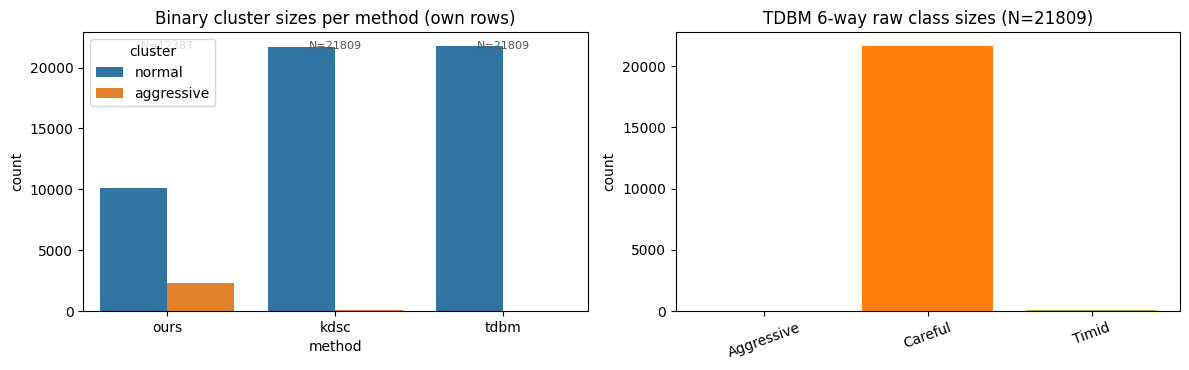

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
sns.barplot(cluster_sizes, x='method', y='count', hue='cluster', ax=axes[0])
axes[0].set_title('Binary cluster sizes per method (own rows)')
axes[0].set_ylabel('count')
for i, m in enumerate(cluster_sizes['method'].unique()):
    n = cluster_sizes.loc[cluster_sizes['method'] == m, 'total_rows_in_method'].iloc[0]
    axes[0].text(i, axes[0].get_ylim()[1] * 0.97, f'N={n}',
                 ha='center', va='top', fontsize=8, color='#555')

class_order = ['Aggressive', 'Reckless', 'Threatening', 'Careful', 'Cautious', 'Timid']
present = [c for c in class_order if c in tdbm6['cluster'].values]
tdbm6_ord = tdbm6.set_index('cluster').loc[present].reset_index()
axes[1].bar(tdbm6_ord['cluster'], tdbm6_ord['count'],
             color=['#d62728', '#ff7f0e', '#bcbd22', '#17becf', '#1f77b4', '#7f7f7f'][:len(present)])
axes[1].set_title(f'TDBM 6-way raw class sizes (N={len(tdbm)})')
axes[1].set_ylabel('count')
axes[1].tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(FIG_DIR / 'cluster_sizes.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Prediction error per cluster

If a method's `aggressive` cluster really captures harder-to-predict driving, MTR's prediction error on that cluster should be higher than on `normal`. We report:

- `mtr_minfde6`: best-of-6-mode FDE (primary).
- `mtr_minade6`: best-of-6-mode ADE.
- `cv_fde`: constant-velocity FDE (sanity reference; pure kinematic difficulty signal).

Per method, per cluster: count, mean, std, p50, p90.

In [5]:
ERROR_COLS = ['mtr_minfde6', 'mtr_minade6', 'cv_fde', 'cv_ade', 'mtr_miss_rate']

print('Non-null counts of error cols per table:')
for m, (df, _) in TABLES.items():
    avail = [c for c in ERROR_COLS if c in df.columns]
    print(f'  {m}:')
    for c in avail:
        print(f'    {c}: {df[c].notna().sum()} / {len(df)}')

def _per_cluster(df: pd.DataFrame, method: str, label_col: str) -> pd.DataFrame:
    out_rows = []
    for label, sub in df.groupby(label_col):
        row = {'method': method, 'cluster': label, 'count': int(len(sub))}
        for c in ERROR_COLS:
            if c not in df.columns:
                continue
            v = sub[c].dropna()
            if len(v) == 0:
                continue
            row[f'{c}_mean']   = float(v.mean())
            row[f'{c}_std']    = float(v.std(ddof=1)) if len(v) > 1 else float('nan')
            row[f'{c}_median'] = float(v.median())
            row[f'{c}_p90']    = float(v.quantile(0.90))
        out_rows.append(row)
    return pd.DataFrame(out_rows)

binary_stats = pd.concat(
    [_per_cluster(df, m, col) for m, (df, col) in TABLES.items()],
    ignore_index=True,
)
binary_stats.to_csv(OUT_DIR / 'prediction_error_by_cluster_binary.csv', index=False)
binary_stats.round(3)

Non-null counts of error cols per table:
  ours:
    mtr_minfde6: 12387 / 12387
    mtr_minade6: 12387 / 12387
    cv_fde: 12387 / 12387
    cv_ade: 12387 / 12387
    mtr_miss_rate: 12387 / 12387
  kdsc:
    mtr_minfde6: 21809 / 21809
    mtr_minade6: 21809 / 21809
    cv_fde: 21809 / 21809
    cv_ade: 21809 / 21809
    mtr_miss_rate: 21809 / 21809
  tdbm:
    mtr_minfde6: 21809 / 21809
    mtr_minade6: 21809 / 21809
    cv_fde: 21809 / 21809
    cv_ade: 21809 / 21809
    mtr_miss_rate: 21809 / 21809


,method,cluster,count,mtr_minfde6_mean,mtr_minfde6_std,mtr_minfde6_median,mtr_minfde6_p90,mtr_minade6_mean,mtr_minade6_std,mtr_minade6_median,...,cv_fde_median,cv_fde_p90,cv_ade_mean,cv_ade_std,cv_ade_median,cv_ade_p90,mtr_miss_rate_mean,mtr_miss_rate_std,mtr_miss_rate_median,mtr_miss_rate_p90
0,ours,aggressive,2269,2.370,1.925,2.005,4.076,1.156,0.782,1.011,...,21.644,36.151,7.943,4.415,7.958,13.584,0.501,0.500,1.0,1.0
1,ours,normal,10118,1.586,1.182,1.429,2.746,0.789,0.500,0.705,...,7.857,22.643,3.848,3.174,2.932,8.416,0.284,0.451,0.0,1.0
2,kdsc,aggressive,84,1.767,1.178,1.643,3.035,1.227,0.623,1.165,...,12.034,28.082,5.357,3.922,4.706,10.697,0.405,0.494,0.0,1.0
3,kdsc,normal,21725,1.730,1.493,1.487,3.042,0.872,0.637,0.748,...,11.023,27.372,4.892,3.845,3.986,10.303,0.313,0.464,0.0,1.0
4,tdbm,aggressive,3,0.756,0.853,0.435,1.466,0.709,0.356,0.910,...,7.929,11.923,2.892,1.822,3.918,3.959,0.000,0.000,0.0,0.0
5,tdbm,normal,21806,1.731,1.492,1.488,3.043,0.873,0.637,0.749,...,11.028,27.376,4.894,3.846,3.989,10.304,0.313,0.464,0.0,1.0


In [6]:
# TDBM 6-way (on TDBM row set only)
tdbm6_stats = _per_cluster(tdbm, 'tdbm_raw', 'tdbm_raw_style_label')
tdbm6_stats.to_csv(OUT_DIR / 'prediction_error_by_cluster_tdbm6.csv', index=False)
tdbm6_stats.round(3)

,method,cluster,count,mtr_minfde6_mean,mtr_minfde6_std,mtr_minfde6_median,mtr_minfde6_p90,mtr_minade6_mean,mtr_minade6_std,mtr_minade6_median,...,cv_fde_median,cv_fde_p90,cv_ade_mean,cv_ade_std,cv_ade_median,cv_ade_p90,mtr_miss_rate_mean,mtr_miss_rate_std,mtr_miss_rate_median,mtr_miss_rate_p90
0,tdbm_raw,Aggressive,3,0.756,0.853,0.435,1.466,0.709,0.356,0.910,...,7.929,11.923,2.892,1.822,3.918,3.959,0.000,0.000,0.0,0.0
1,tdbm_raw,Careful,21687,1.730,1.493,1.488,3.042,0.873,0.637,0.748,...,11.029,27.372,4.892,3.845,3.987,10.303,0.313,0.464,0.0,1.0
2,tdbm_raw,Timid,119,1.809,1.257,1.637,3.098,0.941,0.586,0.904,...,10.418,27.862,5.268,4.029,4.639,10.594,0.370,0.485,0.0,1.0


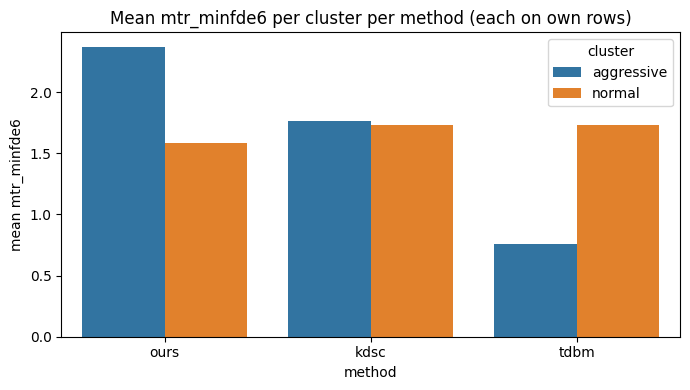

method    cluster  mean   sem     n
  ours aggressive 2.370 0.040  2269
  ours     normal 1.586 0.012 10118
  kdsc aggressive 1.767 0.129    84
  kdsc     normal 1.730 0.010 21725
  tdbm aggressive 0.756 0.493     3
  tdbm     normal 1.731 0.010 21806


In [7]:
# Bar plot: mean FDE per cluster per method, each on its own rows
PRIMARY = 'mtr_minfde6'
plot_rows = []
for m, (df, col) in TABLES.items():
    if PRIMARY not in df.columns:
        continue
    for label, sub in df.groupby(col):
        v = sub[PRIMARY].dropna()
        if not len(v):
            continue
        plot_rows.append({'method': m, 'cluster': label,
                          'mean': float(v.mean()),
                          'sem':  float(v.sem()),
                          'n':    int(len(v))})
plot_df = pd.DataFrame(plot_rows)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(plot_df, x='method', y='mean', hue='cluster', ax=ax)
ax.set_ylabel(f'mean {PRIMARY}')
ax.set_title(f'Mean {PRIMARY} per cluster per method (each on own rows)')
fig.tight_layout()
fig.savefig(FIG_DIR / f'mean_{PRIMARY}_by_method.png', dpi=120, bbox_inches='tight')
plt.show()
print(plot_df.round(3).to_string(index=False))

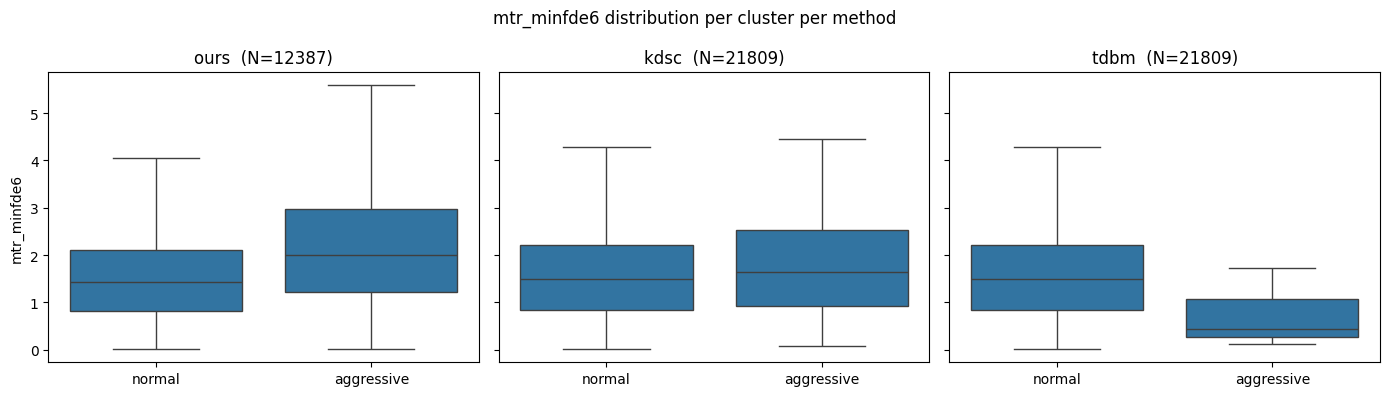

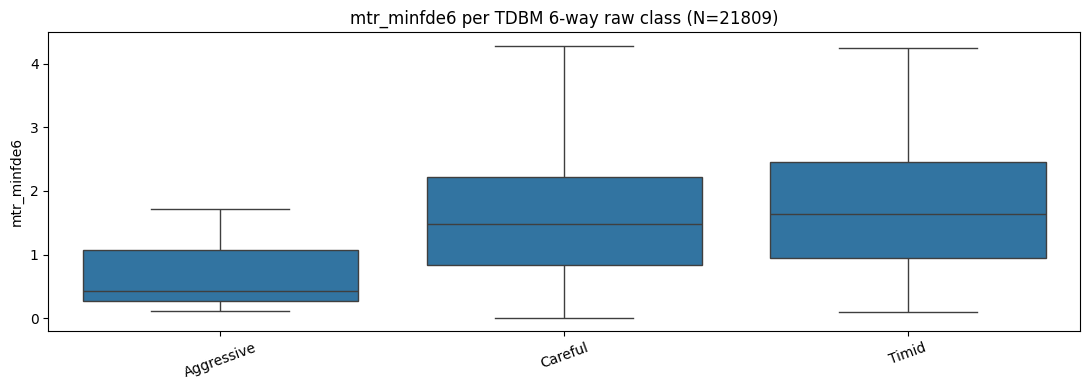

In [8]:
# Boxplots: per-method FDE distribution per cluster
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (m, (df, col)) in zip(axes, TABLES.items()):
    if PRIMARY not in df.columns:
        ax.set_visible(False); continue
    sub = df[[col, PRIMARY]].dropna()
    sns.boxplot(data=sub, x=col, y=PRIMARY,
                order=['normal', 'aggressive'], ax=ax, showfliers=False)
    ax.set_title(f'{m}  (N={len(sub)})')
    ax.set_xlabel('')
fig.suptitle(f'{PRIMARY} distribution per cluster per method')
fig.tight_layout()
fig.savefig(FIG_DIR / f'box_{PRIMARY}_by_method.png', dpi=120, bbox_inches='tight')
plt.show()

# TDBM 6-way box (on tdbm rows only)
if PRIMARY in tdbm.columns:
    order = ['Aggressive', 'Reckless', 'Threatening', 'Careful', 'Cautious', 'Timid']
    present = [c for c in order if c in tdbm['tdbm_raw_style_label'].unique()]
    fig, ax = plt.subplots(figsize=(11, 4))
    sub = tdbm[['tdbm_raw_style_label', PRIMARY]].dropna()
    sns.boxplot(data=sub, x='tdbm_raw_style_label', y=PRIMARY,
                order=present, ax=ax, showfliers=False)
    ax.set_title(f'{PRIMARY} per TDBM 6-way raw class (N={len(sub)})')
    ax.set_xlabel(''); ax.tick_params(axis='x', rotation=20)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'box_{PRIMARY}_tdbm6.png', dpi=120, bbox_inches='tight')
    plt.show()

## 4. Feature histograms per cluster (per method)

Same per-cluster distribution plots used in the clustering notebooks, separately for each method **on its own row set**.

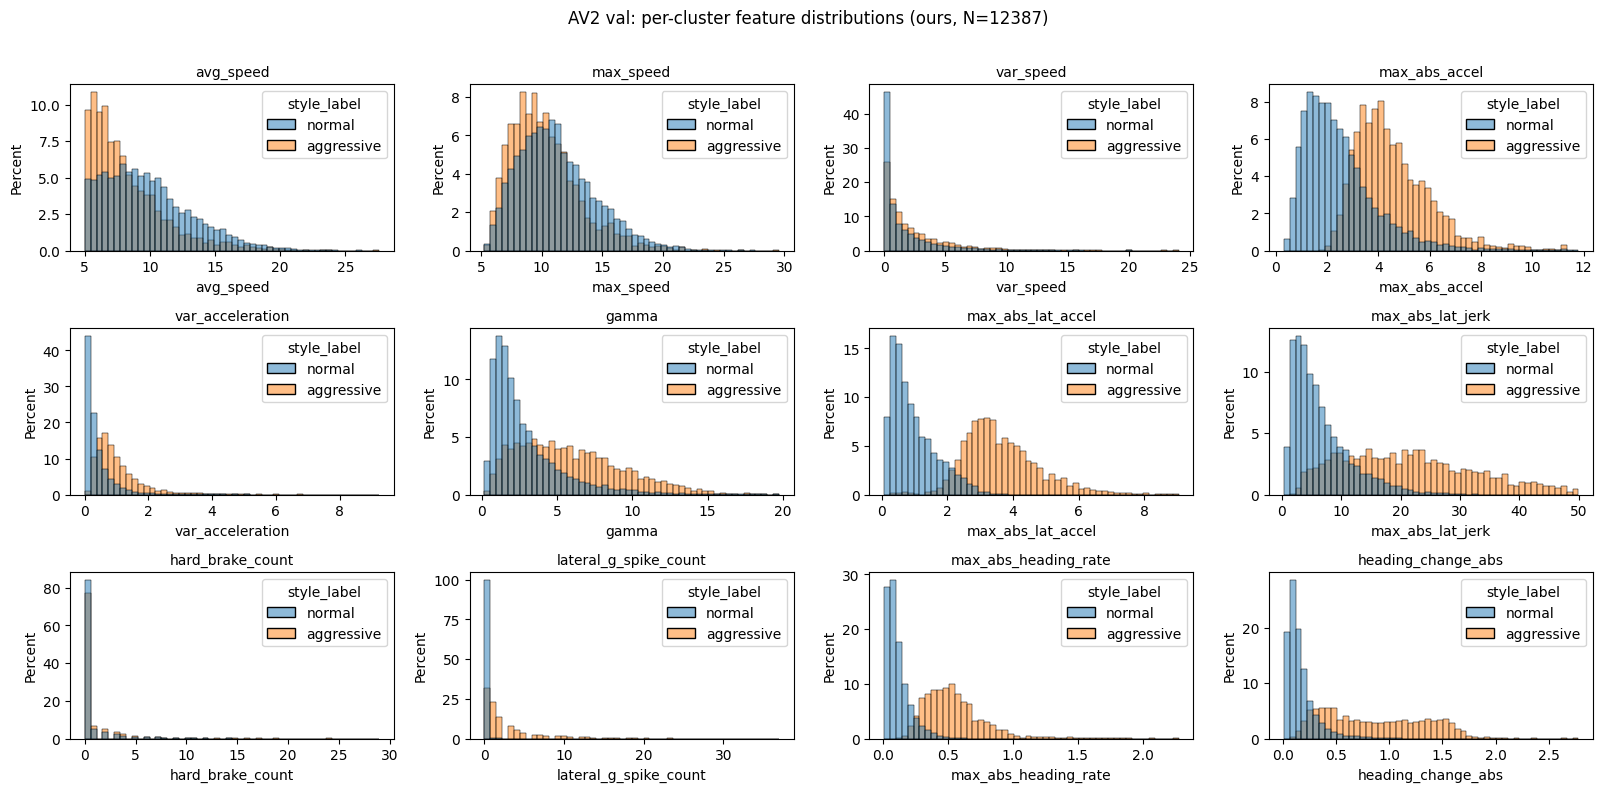

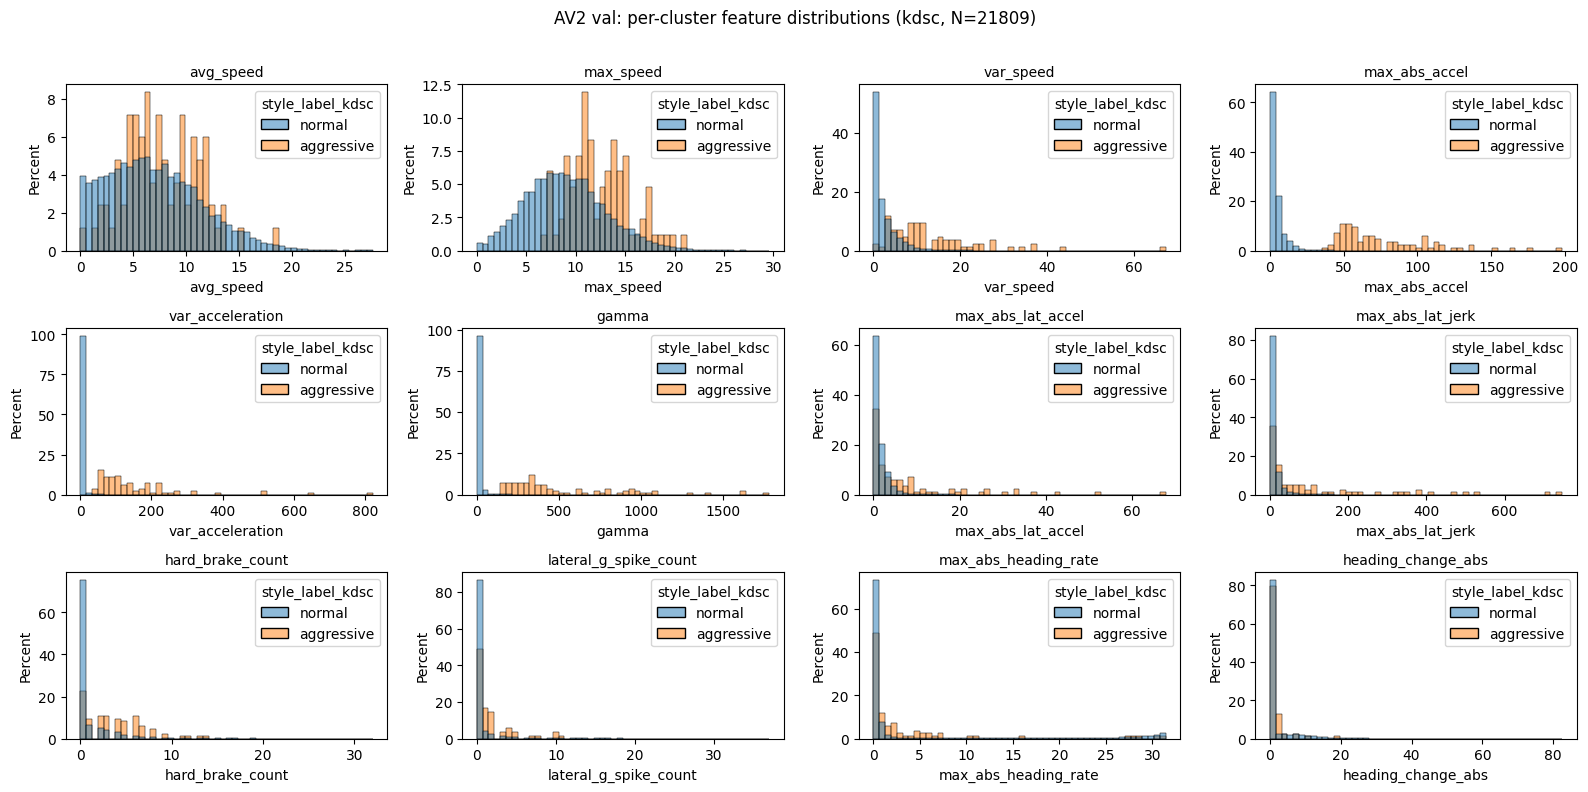

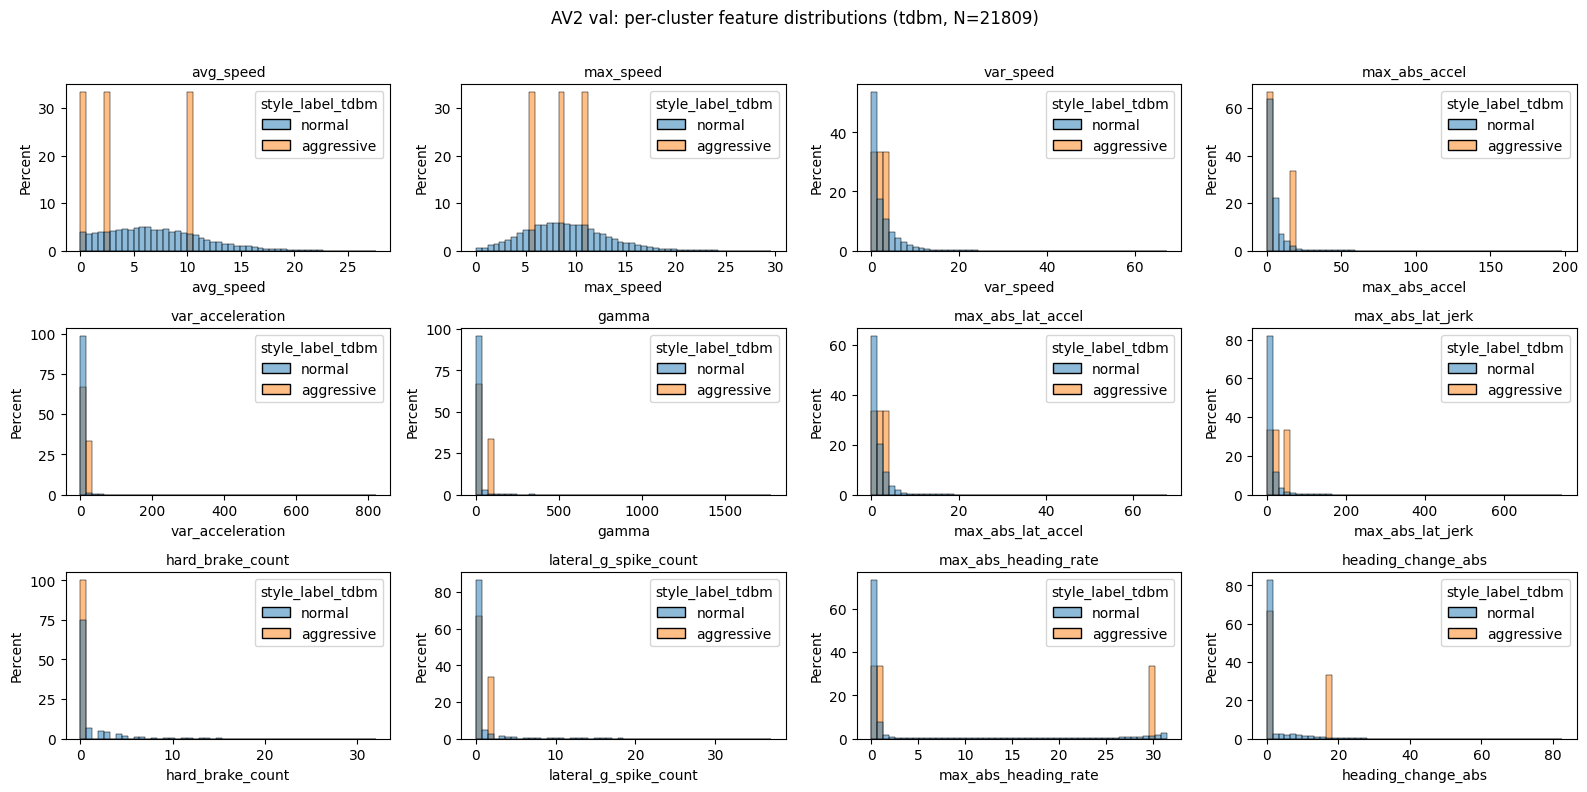

In [9]:
HIST_FEATURES = [
    'avg_speed', 'max_speed', 'var_speed',
    'max_abs_accel', 'var_acceleration', 'gamma',
    'max_abs_lat_accel', 'max_abs_lat_jerk',
    'hard_brake_count', 'lateral_g_spike_count',
    'max_abs_heading_rate', 'heading_change_abs',
]

def _grid(df: pd.DataFrame, method: str, label_col: str, bins: int = 50):
    feats = [c for c in HIST_FEATURES if c in df.columns]
    if not feats:
        print(f'{method}: no histogram features available'); return None
    cols = 4
    rows = (len(feats) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 2.6 * rows))
    axes = np.array(axes).reshape(rows, cols)
    for ax, feat in zip(axes.flat, feats):
        sns.histplot(data=df, x=feat, hue=label_col,
                     stat='percent', common_norm=False, bins=bins, ax=ax,
                     hue_order=['normal', 'aggressive'])
        ax.set_title(feat, fontsize=10)
    for ax in axes.flat[len(feats):]:
        ax.set_visible(False)
    fig.suptitle(f'AV2 val: per-cluster feature distributions ({method}, N={len(df)})', y=1.01)
    fig.tight_layout()
    out = FIG_DIR / f'histograms_{method}.png'
    fig.savefig(out, dpi=120, bbox_inches='tight')
    plt.show()
    return out

for m, (df, col) in TABLES.items():
    _grid(df, m, col)

In [ ]:
# TDBM 6-way histograms (on TDBM row set)
TDBM6_FEATURES = [c for c in [
    'avg_speed', 'max_abs_accel', 'max_abs_lat_accel',
    'hard_brake_count', 'lateral_g_spike_count', 'gamma',
] if c in tdbm.columns]

order = ['Aggressive', 'Reckless', 'Threatening', 'Careful', 'Cautious', 'Timid']
present = [c for c in order if c in tdbm['tdbm_raw_style_label'].unique()]

cols = 3
rows = (len(TDBM6_FEATURES) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3 * rows))
axes = np.array(axes).reshape(rows, cols)
for ax, feat in zip(axes.flat, TDBM6_FEATURES):
    sns.histplot(data=tdbm, x=feat, hue='tdbm_raw_style_label',
                 stat='percent', common_norm=False, bins=50, ax=ax,
                 hue_order=present)
    ax.set_title(feat, fontsize=10)
for ax in axes.flat[len(TDBM6_FEATURES):]:
    ax.set_visible(False)
fig.suptitle(f'AV2 val: per-class feature distributions (TDBM 6-way, N={len(tdbm)})', y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / 'histograms_tdbm6.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Save report

In [ ]:
report = {
    'dataset': DATASET,
    'row_counts_per_method': {m: int(len(df)) for m, (df, _) in TABLES.items()},
    'cluster_sizes_binary':  cluster_sizes.to_dict(orient='records'),
    'cluster_sizes_tdbm_raw': tdbm6.to_dict(orient='records'),
    'prediction_error_columns': ERROR_COLS,
    'prediction_error_binary': binary_stats.to_dict(orient='records'),
    'prediction_error_tdbm6': tdbm6_stats.to_dict(orient='records'),
    'histogram_features': HIST_FEATURES,
    'note': 'All statistics are computed on each method\'s own cleaned row set. No inner join.',
}
with open(OUT_DIR / 'stats_report.json', 'w') as f:
    json.dump(report, f, indent=2, default=float)
print('Saved:')
for p in sorted(OUT_DIR.rglob('*')):
    if p.is_file():
        print(' ', p.relative_to(REPO_ROOT))